# Student Performance Data Analysis

## Objective

The goal of this project is to perform data exploration and cleaning on a student performance dataset. The analysis focuses on understanding score distributions, identifying data quality issues, and extracting insights that can help educators improve student outcomes.

## 1. Import Required Libraries

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)



## 2. Load Dataset

In [66]:
df = pd.read_csv("../data/StudentsPerformance.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Dataset Preview

In [67]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 4. Dataset Dimensions

In [68]:
rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 1000
Number of Columns : 8


## 5. Dataset Information

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## 6. Missing Values Analysis

Before performing any analysis, it is important to check whether the dataset contains missing values. Missing values can affect statistical summaries and model performance.

In [70]:
missing_values = df.isnull().sum()

missing_values

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [71]:
print("Total Missing Values:", missing_values.sum())

Total Missing Values: 0


## 7. Duplicate Record Analysis

Duplicate records can introduce bias in data analysis. Therefore, duplicate entries are checked before proceeding further.

In [72]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


In [73]:
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate records found.")

No duplicate records found.


## 8. Column Name Standardization

Column names are standardized to improve readability and maintain consistency during analysis.

In [74]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

### Column Name Standardization

The original dataset contained column names with spaces, which can make data manipulation less convenient. Column names were converted to lowercase and spaces were replaced with underscores to improve consistency and readability.

In [75]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

## 9. Score Distribution Analysis

Understanding score distributions helps identify overall student performance trends and detect whether scores are concentrated around specific ranges.

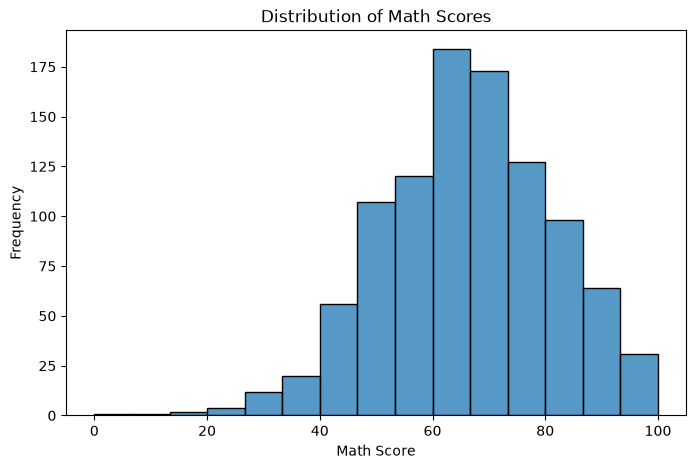

In [76]:
plt.figure(figsize=(8, 5))

sns.histplot(df["math_score"], bins=15)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.show()

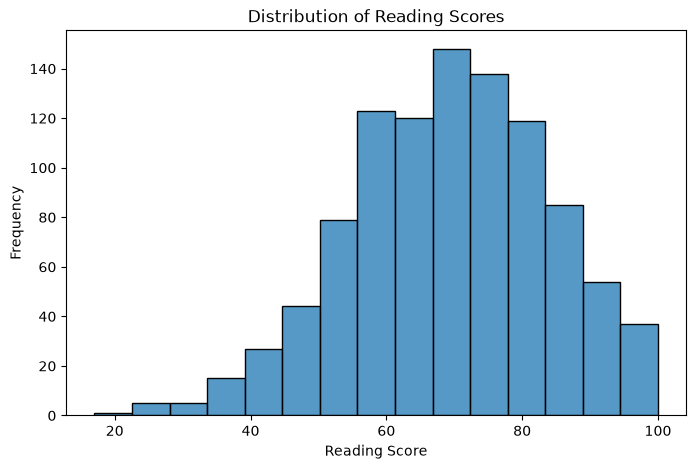

In [77]:
plt.figure(figsize=(8, 5))

sns.histplot(df["reading_score"], bins=15)

plt.title("Distribution of Reading Scores")
plt.xlabel("Reading Score")
plt.ylabel("Frequency")

plt.show()

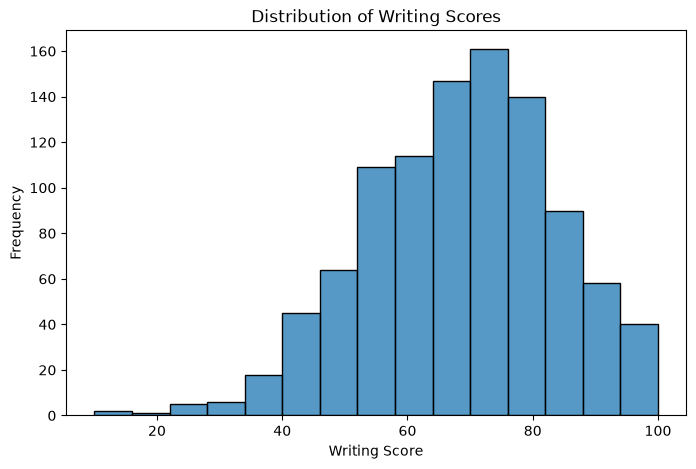

In [78]:
plt.figure(figsize=(8, 5))

sns.histplot(df["writing_score"], bins=15)

plt.title("Distribution of Writing Scores")
plt.xlabel("Writing Score")
plt.ylabel("Frequency")

plt.show()

## 10. Statistical Summary

Basic statistical measures provide an overview of student performance across different subjects.

In [79]:
df[["math_score", "reading_score", "writing_score"]].describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 11. Correlation Analysis

Correlation analysis helps understand relationships between different academic scores.

In [80]:
score_columns = [
    "math_score",
    "reading_score",
    "writing_score"
]

correlation_matrix = df[score_columns].corr()

correlation_matrix

,math_score,reading_score,writing_score
math_score,1.000000,0.817580,0.802642
reading_score,0.817580,1.000000,0.954598
writing_score,0.802642,0.954598,1.000000


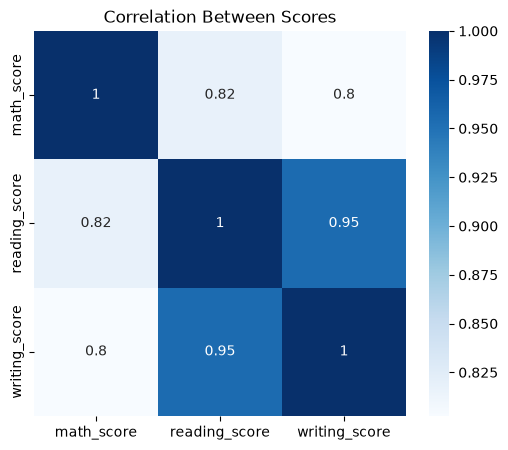

In [81]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Between Scores")

plt.show()

## 12. Impact of Test Preparation Course

This analysis evaluates whether completing a test preparation course is associated with improved student performance.

In [82]:
score_columns = [
    "math_score",
    "reading_score",
    "writing_score"
]

df.groupby("test_preparation_course")[score_columns].mean()

,math_score,reading_score,writing_score
test_preparation_course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


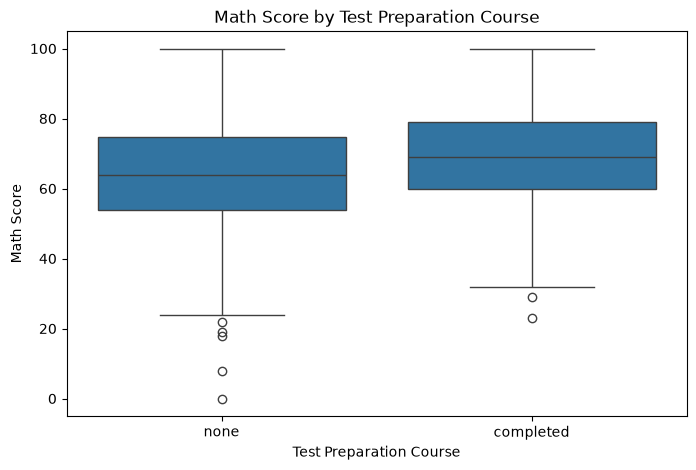

In [83]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="test_preparation_course",
    y="math_score",
    data=df
)

plt.title("Math Score by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")

plt.show()

## 13. Key Insights

### Insight 1: Test Preparation Improves Performance

Students who completed the test preparation course consistently achieved higher average scores across all subjects.

- Math Score Improvement: ~5.6 points
- Reading Score Improvement: ~7.4 points
- Writing Score Improvement: ~9.9 points

This suggests that structured preparation programs can positively influence student academic performance.

---

### Insight 2: Reading and Writing Skills Are Strongly Related

The correlation analysis revealed a very strong relationship (0.95) between reading and writing scores.

Students who perform well in reading are likely to perform well in writing as well.

---

### Insight 3: Most Students Perform Within a Moderate Score Range

Score distributions indicate that the majority of students score between 50 and 80 marks, with relatively few extreme low or high performers.

---

### Insight 4: Math Is the Most Challenging Subject

Among the three subjects, mathematics has the lowest average score, indicating that additional support may be beneficial for students struggling with math concepts.

## 14. Recommendations

Based on the analysis, the following recommendations can be made:

1. Encourage participation in test preparation programs, as students who completed them demonstrated better performance.

2. Provide additional academic support for mathematics, which showed the lowest average score among the subjects.

3. Strengthen reading development initiatives, as improvements in reading skills may also positively impact writing performance.

4. Identify students scoring below the average range and provide targeted intervention programs.

In [84]:
df.to_csv(
    "../data/cleaned_student_performance.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
